Running A* with Dubins edges...
  grid_res=2.75, heading_bins=16, max nodes: 3344
  A*: 50 nodes expanded, queue: 36
  A*: 100 nodes expanded, queue: 80
  A*: 150 nodes expanded, queue: 88
  A*: 200 nodes expanded, queue: 70
  A*: 250 nodes expanded, queue: 82
  A*: 300 nodes expanded, queue: 97
  A*: 350 nodes expanded, queue: 90
  A*: 400 nodes expanded, queue: 71
  A*: 450 nodes expanded, queue: 65
  A*: 500 nodes expanded, queue: 72
  A*: 550 nodes expanded, queue: 97
  A*: better path found at 585 nodes, cost=112.3
  A*: optimal path confirmed after 585 nodes
Final path: 30 waypoints
Thinned waypoints: 7


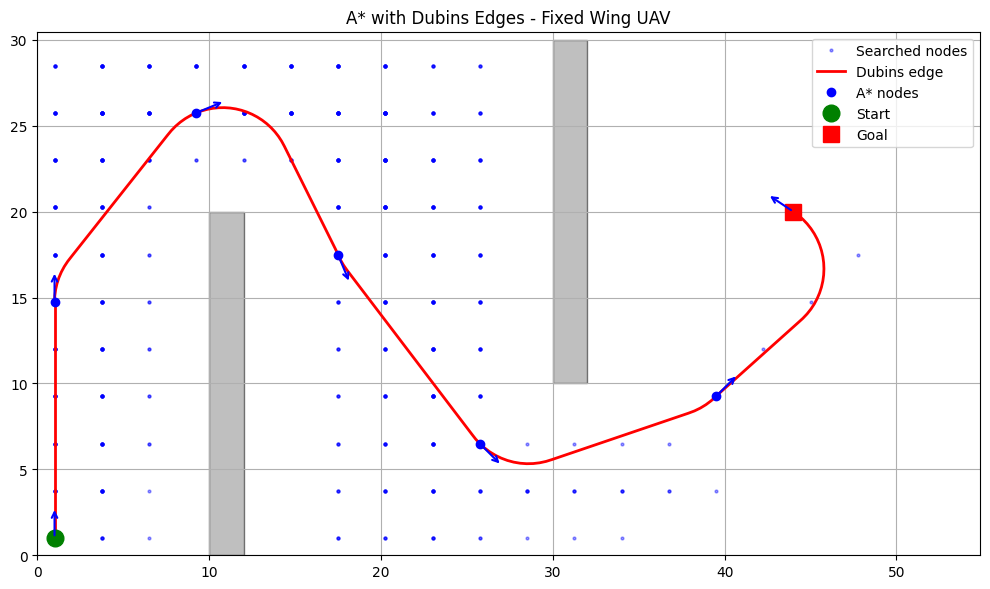

In [1]:
from optimized_3D_planning import run_traj
from path_planner import plan_fixed_wing, RectWall, plot_plan, plot_trajectory_2d, plot_3d_with_walls, plot_velocities, plot_position, plot_acceleration
import numpy as np

# ─────────────────────────────────────────────
# Environment Setup
# ─────────────────────────────────────────────

walls = [ # (x_min, x_max, y_min, y_max, height)
    RectWall(10, 12, 0,  20, height=40.0),
    RectWall(30, 32, 10, 30, height=40.0)
]

# (x, y, z, heading_degrees) — heading: 0=east, 90=north, 180=west, 270=south
start = (1.0,  1.0,  0.0,  90.0)
goal  = (44.0, 20.0, 35.0, 0.0)  # last value ignored, UAV arrives naturally
R           = 4.0   # minimum turn radius (meters)
uav_radius = 1.3   # UAV collision margin — increase to stay further from walls

# Path Planning (A* with Dubins edges)
result = plan_fixed_wing(
    start, goal, walls, R=R,
    grid_res=2.75, heading_bins=16,
    x_bounds=(0, 54.864), y_bounds=(0, 30.48), #Purdue UAS Research and Test Facility
    w_turn=5.0, uav_radius=uav_radius
)

# Thin waypoints — keep every Nth for polynomial optimizer
# Lower N = closer to A* path but slower, higher N = faster but more corner cutting
N = 5
indices = list(range(0, len(result['x1']), N))
if indices[-1] != len(result['x1']) - 1:
    indices.append(len(result['x1']) - 1)

result['x1']   = [result['x1'][i]  for i in indices]
result['y1']   = [result['y1'][i]  for i in indices]
result['z1']   = [result['z1'][i]  for i in indices]
result['path'] = [result['path'][i] for i in indices]
print("Thinned waypoints:", len(result['x1']))

# Plot 1: A* search with Dubins edges
plot_plan(result['path'], walls, start, goal,
          x_bounds=(0, 54.864), y_bounds=(0, 30.48), R=R,
          visited=result['visited'])

x1: [1.0, 1.0, 9.25, 17.5, 25.75, 39.5, 44.0]
y1: [1.0, 14.75, 25.75, 17.5, 6.5, 9.25, 20.0]
z1: [0.0, 6.0344827586206895, 12.068965517241379, 18.103448275862068, 24.137931034482758, 30.17241379310345, 35.0]
headings: [np.float64(1.5707963267948966), np.float64(1.5707963267948966), np.float64(0.39269908169872414), np.float64(5.105088062083414), np.float64(5.497787143782138), np.float64(0.7853981633974483), np.float64(2.5535900500422257)]
n waypoints: 7
---------------------------------------------
REPORT
Observed Speed Range: nan to nan m/s
Target Window:        3 to 10 m/s
Leg Times: [3.15 3.14 3.44 3.15 3.3  3.42]
Total Time: 19.60 s
---------------------------------------------


c:\Users\podde\Desktop\Fixed-Wing-Trajectory-Optimizer\optimized_3D_planning.py:188: RuntimeWarning: divide by zero encountered in divide
  vx_t = np.diff(traj_x['x']) / dt
c:\Users\podde\Desktop\Fixed-Wing-Trajectory-Optimizer\optimized_3D_planning.py:189: RuntimeWarning: divide by zero encountered in divide
  vy_t = np.diff(traj_y['x']) / dt
c:\Users\podde\Desktop\Fixed-Wing-Trajectory-Optimizer\optimized_3D_planning.py:189: RuntimeWarning: invalid value encountered in divide
  vy_t = np.diff(traj_y['x']) / dt


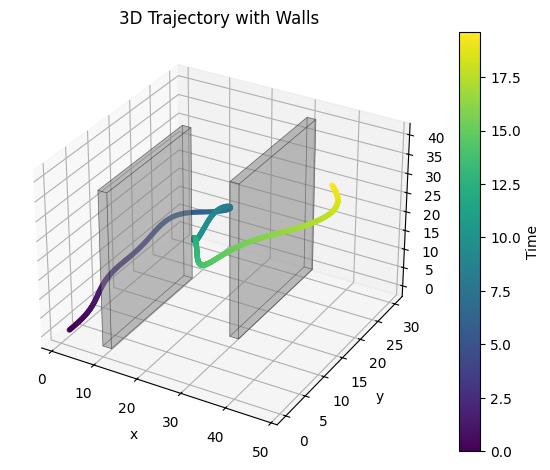

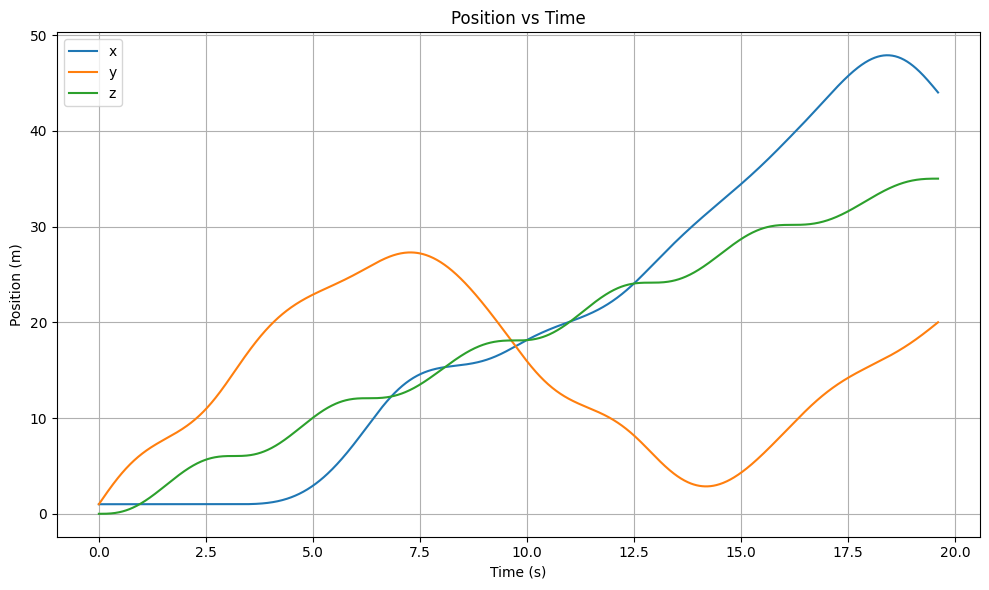

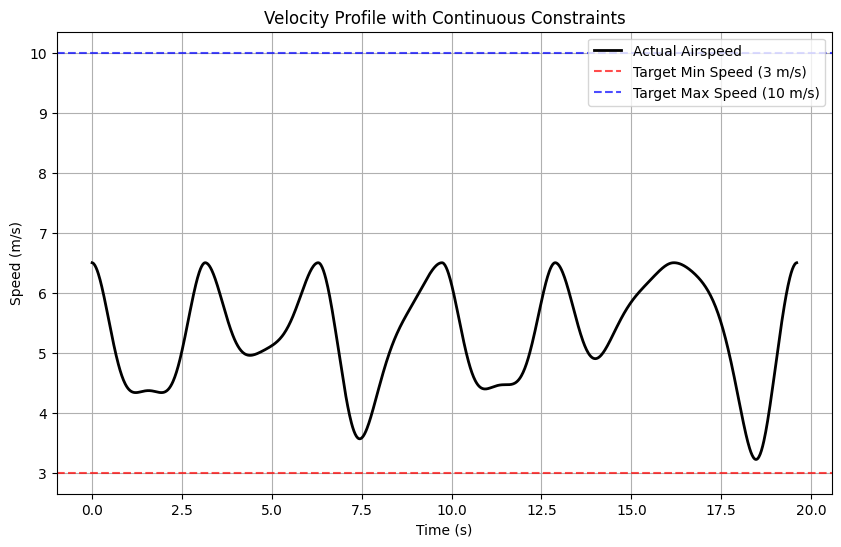

KeyError: 'coeffs_x'

In [2]:
# ─────────────────────────────────────────────
# Cell 2: Polynomial Trajectory Optimization
# ─────────────────────────────────────────────
n = len(result['x1'])

# Renamed to match the new function definition
v_min = 3
v_max = 10
k_time = 50 # High k_time forces the solver to prioritize speed over smoothness

headings = [result['path'][i][2] for i in range(n)]

print("x1:", result['x1'])
print("y1:", result['y1'])
print("z1:", result['z1'])
print("headings:", headings)
print("n waypoints:", len(result['x1']))

path_leg = run_traj(
    result['x1'], result['y1'], result['z1'], 
    headings,
    k_time = k_time,
    v_min = v_min,
    v_max = v_max
)

if path_leg is not None:
    # All these lines only run if a valid path exists
    plot_3d_with_walls(path_leg, walls)
    plot_position(path_leg)
    plot_velocities(path_leg, v_min=v_min, v_max=v_max)
    plot_acceleration(path_leg)
    
    total_time = path_leg['t_x'][-1]
    print(f"Thinned waypoints: {len(result['x1'])}")
    print(f"Total optimized flight time: {total_time:.2f} seconds")
else:
    # This runs if the "Brick Wall" was hit
    print("Could not plot: No valid trajectory found.")
    print("Try increasing the v_min/v_max range or reducing the sharpness of your turns.")

In [ ]:
import csv
#Data for ROS: time (s), x (m), y (m), z (m)

# Prepare data for export
time = path_leg['t_x']
x = path_leg['x']
y = path_leg['y']
z = path_leg['z']

# Write to CSV using built-in module
with open('flight_trajectory.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['time_s', 'x_m', 'y_m', 'z_m']) # Headers
    writer.writerows(zip(time, x, y, z)) # Data rows
print("Trajectory data exported to flight_trajectory.csv")